In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [20]:
df_vitruve = pd.read_csv('../data/TEST_31-03-2025.csv', skiprows=1, index_col = False)

In [21]:
def mean_relative_error(y_true, y_pred):
    """
    Calcula el error relativo medio en porcentaje.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def plot_comparison_by_rep(merged_df, vitruve_col, video_col, title=""):
    """
    Crea un gráfico donde el eje x es la repetición y el eje y muestra los valores de la métrica.
    Se grafican dos series (Vitruve y Video) con líneas y marcadores. También incluye
    líneas de tendencia (regresión lineal) para cada serie.
    """
    rep = merged_df['repetition_index'].astype(int).values
    vitruve_y = merged_df[vitruve_col].astype(str).str.replace(',', '.').astype(float).values
    video_y   = merged_df[video_col].astype(str).str.replace(',', '.').astype(float).values

    plt.figure(figsize=(8,6))
    
    # Graficamos los datos en forma de línea con marcadores
    plt.plot(rep, vitruve_y, marker='o', color='blue', label='Vitruve', alpha=0.7)
    plt.plot(rep, video_y,   marker='s', color='red',  label='Video', alpha=0.7)
    
    # Agregamos líneas de tendencia (regresión lineal) para cada serie
    if len(rep) >= 2:
        # Tendencia para Vitruve
        m_v, b_v = np.polyfit(rep, vitruve_y, 1)
        rep_line = np.linspace(rep.min(), rep.max(), 100)
        vitruve_line = m_v * rep_line + b_v
        plt.plot(rep_line, vitruve_line, linestyle='--', color='blue',
                 label=f"Vitruve fit: y={m_v:.2f}x+{b_v:.2f}")
        
        # Tendencia para Video
        m_vid, b_vid = np.polyfit(rep, video_y, 1)
        video_line = m_vid * rep_line + b_vid
        plt.plot(rep_line, video_line, linestyle='--', color='red',
                 label=f"Video fit: y={m_vid:.2f}x+{b_vid:.2f}")

    plt.xlabel("Repetición")
    plt.ylabel("Valor de la métrica")
    plt.title(title or f"Comparación por repetición: {vitruve_col} vs {video_col}")
    plt.legend()
    plt.grid(True)
    plt.show()

def calculate_r2(y_true, y_pred):
    """
    Calcula el coeficiente de determinación R² usando la fórmula:
    R² = 1 - (Σ(y_true - y_pred)²) / (Σ(y_true - mean(y_true))²)
    """
    import numpy as np
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 1.0

In [22]:
vitruve_columns = ['Fecha repetición', 'Nº Serie', 'Nº Repetición', 'Tipo*', 'VMP (m/s)', 'Velocidad máxima (m/s)', 'ROM (cm)']
video_columns = ['repetition', 'rep_time','ROM (cm)', 'VMED (m/s)', 'VMAX (m/s)']
metrics = [
    ('Vitruve_VMED', 'Video_VMED'),
    ('Vitruve_VMAX', 'Video_VMAX'),
    ('Vitruve_ROM',  'Video_ROM')]

# Squats

## Vista lateral

the reps count measured in video is: 21
the reps count measured in vitruve is: 21
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.1078
 MAE: 0.3203
 MRE: 29.06%

 R²: -101.4666

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0192
 MAE: 0.1208
 MRE: 7.43%

 R²: -6.9796

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 12.2181
 MAE: 3.1690
 MRE: 6.41%

 R²: -2.4511



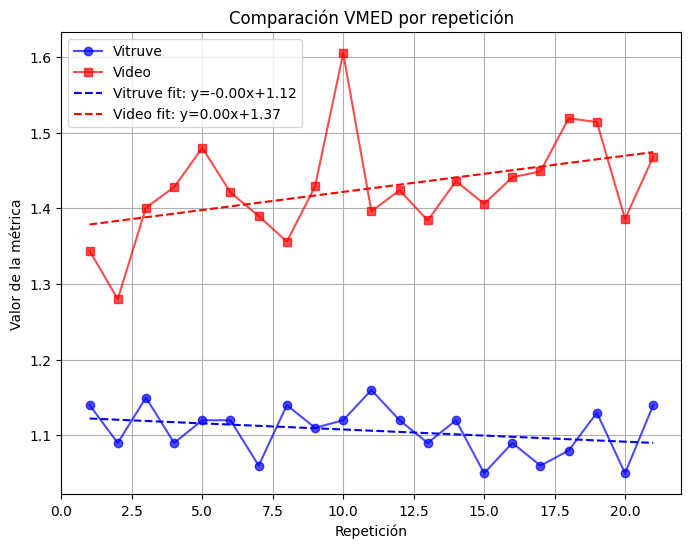

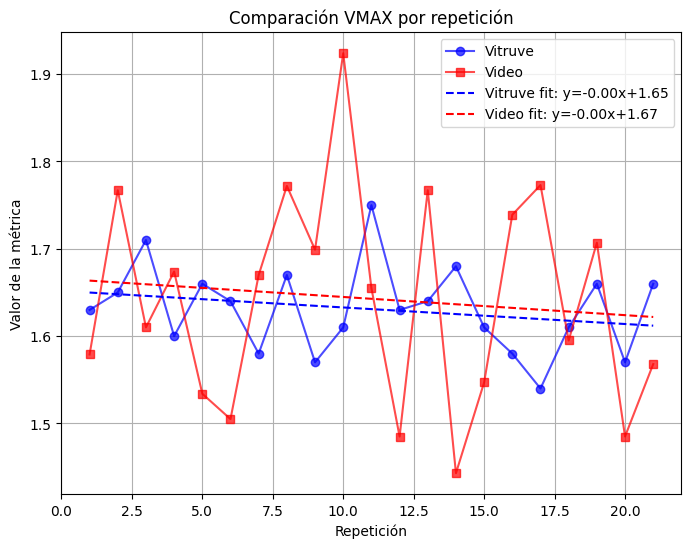

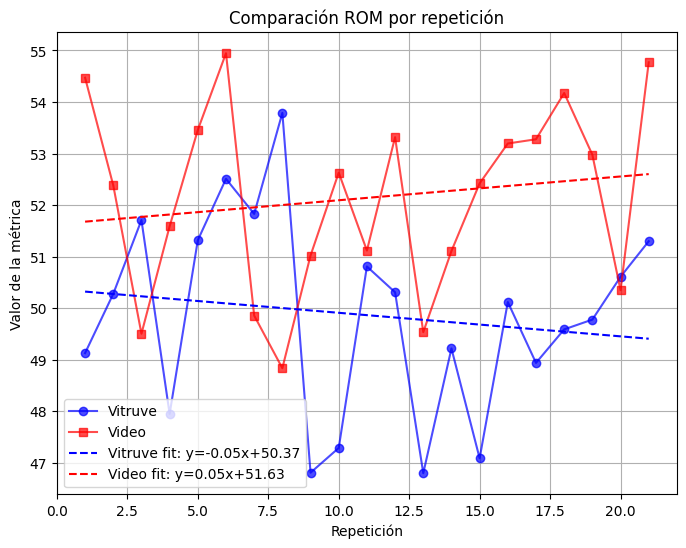

Ratio VMED (Vitruve/Video) = 0.7754448042193811
Ratio VMAX (Vitruve/Video) = 0.9928111774595628
Ratio ROM (Vitruve/Video) = 0.9563710886770501


In [23]:
df_squat_lat1 = pd.read_csv('../data_export/squat/20250403_080631_squat_metrics.csv')
df_squat_lat2 = pd.read_csv('../data_export/squat/20250403_081026_squat_metrics.csv')
df_video_squat_lat = pd.concat([df_squat_lat1, df_squat_lat2], ignore_index=True)
df_video_squat_lat['repetition_index'] = range(1, len(df_video_squat_lat) + 1)
print(f"the reps count measured in video is: {df_video_squat_lat.shape[0]}")

df_vitruve_squat_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([3,4])][df_vitruve['Tipo*']=='C']
df_vitruve_squat_lat['repetition_index'] = range(1, len(df_vitruve_squat_lat) + 1)
print(f"the reps count measured in vitruve is: {df_video_squat_lat.shape[0]}")

df_vitruve_squat_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_squat_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_squat_lat = pd.merge(df_video_squat_lat, df_vitruve_squat_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_squat_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_squat_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_squat_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_squat_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_squat_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_squat_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_squat_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_squat_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

## Vista frontal

the reps count measured in video is: 21
the reps count measured in vitruve is: 21
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.4032
 MAE: 0.6255
 MRE: 56.51%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.6919
 MAE: 0.8227
 MRE: 50.40%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 1217.4951
 MAE: 34.7290
 MRE: 69.65%



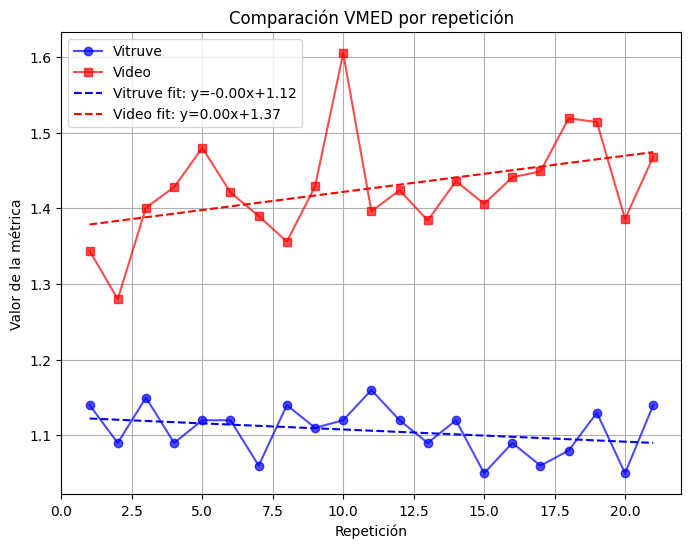

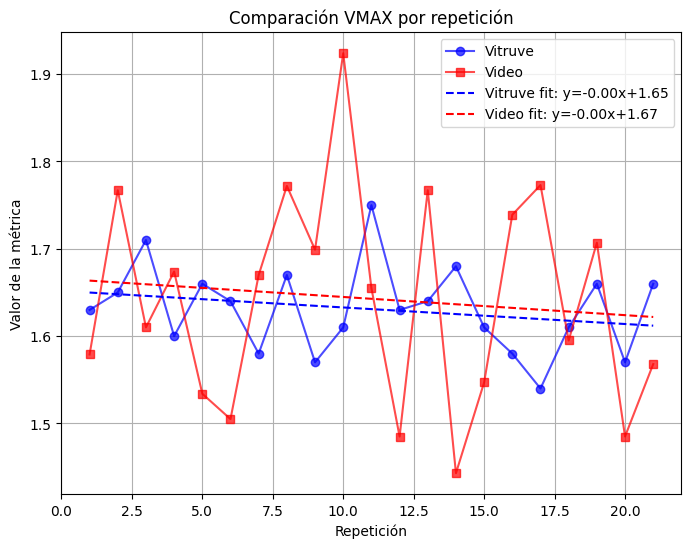

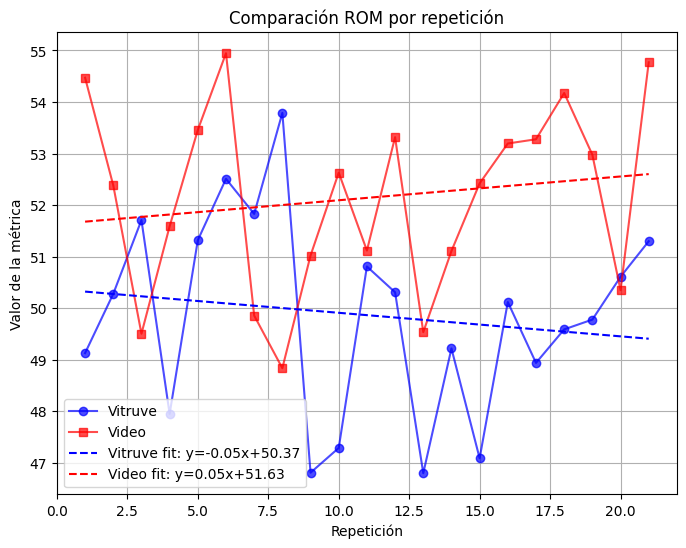

Ratio VMED (Vitruve/Video) = 2.3013671488012672
Ratio VMAX (Vitruve/Video) = 2.017791917049605
Ratio ROM (Vitruve/Video) = 3.2942830807755104


In [24]:
df_squat_front1 = pd.read_csv('../data_export/squat/20250403_075804_squat_metrics.csv')
df_squat_front2 = pd.read_csv('../data_export/squat/20250403_080214_squat_metrics.csv')
df_video_squat_front = pd.concat([df_squat_front1, df_squat_front2], ignore_index=True)
df_video_squat_front['repetition_index'] = range(1, len(df_video_squat_front) + 1)
print(f"the reps count measured in video is: {df_video_squat_front.shape[0]}")

df_vitruve_squat_front =  df_vitruve[df_vitruve['Nº Serie'].isin([3,4])][df_vitruve['Tipo*']=='C']
df_vitruve_squat_front['repetition_index'] = range(1, len(df_vitruve_squat_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_squat_front.shape[0]}")

df_vitruve_squat_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_squat_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_squat_front = pd.merge(df_vitruve_squat_front, df_video_squat_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_squat_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_squat_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

plot_comparison_by_rep(df_squat_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_squat_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_squat_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_squat_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_squat_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_squat_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

# Curl

## Vista lateral

the reps count measured in video is: 24
the reps count measured in vitruve is: 20
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0528
 MAE: 0.1927
 MRE: 14.63%

 R²: -1.7609

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0365
 MAE: 0.1326
 MRE: 6.48%

 R²: -3.8182

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 15.1290
 MAE: 2.5958
 MRE: 4.09%

 R²: -2.7335



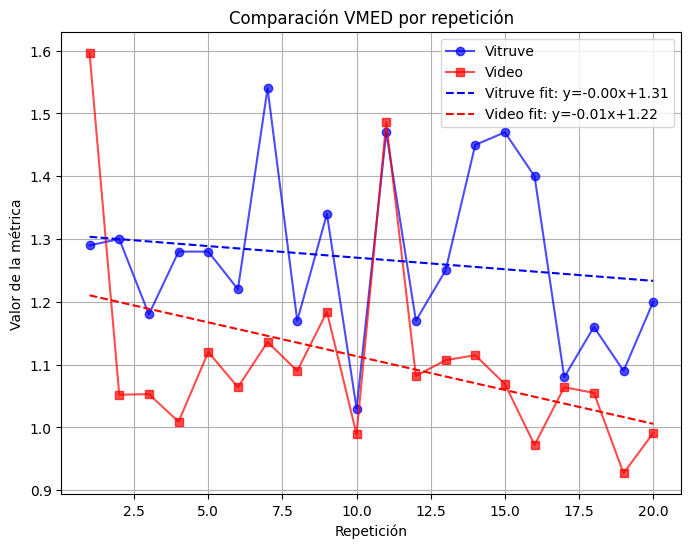

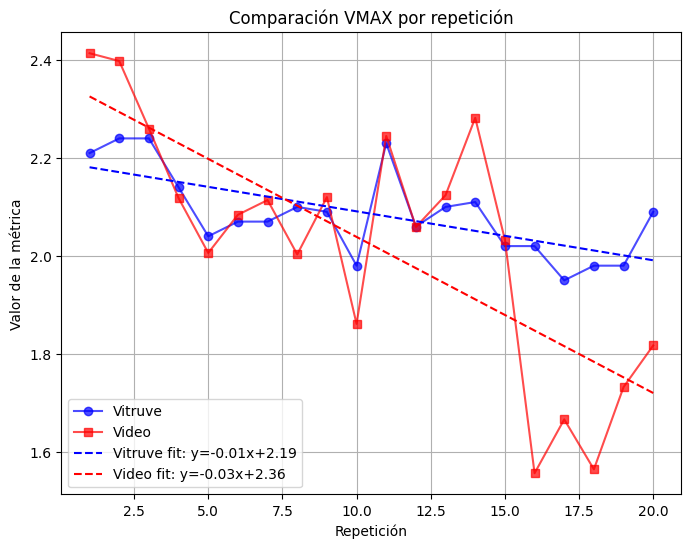

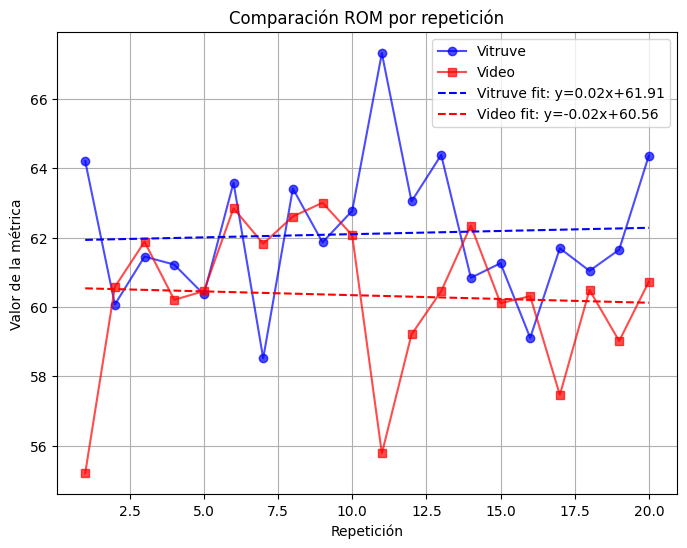

Ratio VMED (Vitruve/Video) = 1.1448039348404855
Ratio VMAX (Vitruve/Video) = 1.0312438204469054
Ratio ROM (Vitruve/Video) = 1.029469658857432


In [30]:
df_curl_lat1 = pd.read_csv('../data_export/curl/20250403_084624_curl_metrics.csv')
df_curl_lat2 = pd.read_csv('../data_export/curl/20250403_085336_curl_metrics.csv')
df_video_curl_lat = pd.concat([df_curl_lat1, df_curl_lat2], ignore_index=True)
df_video_curl_lat['repetition_index'] = range(1, len(df_video_curl_lat) + 1)
print(f"the reps count measured in video is: {df_video_curl_lat.shape[0]}")

df_vitruve_curl_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([5,6])][df_vitruve['Tipo*']=='C']
df_vitruve_curl_lat['repetition_index'] = range(1, len(df_vitruve_curl_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_curl_lat.shape[0]}")



df_vitruve_curl_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_curl_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_curl_lat = pd.merge(df_vitruve_curl_lat, df_video_curl_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_curl_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_curl_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    r2 = calculate_r2(y_true, y_pred)

    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")
    print(f" R²: {r2:.4f}\n")

plot_comparison_by_rep(df_curl_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_curl_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_curl_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_curl_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_curl_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_curl_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


## Vista frontal

the reps count measured in video is: 21
the reps count measured in vitruve is: 22
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.5944
 MAE: 0.6626
 MRE: 84.34%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 1.6152
 MAE: 1.2000
 MRE: 90.51%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 1199.8106
 MAE: 32.4083
 MRE: 81.98%



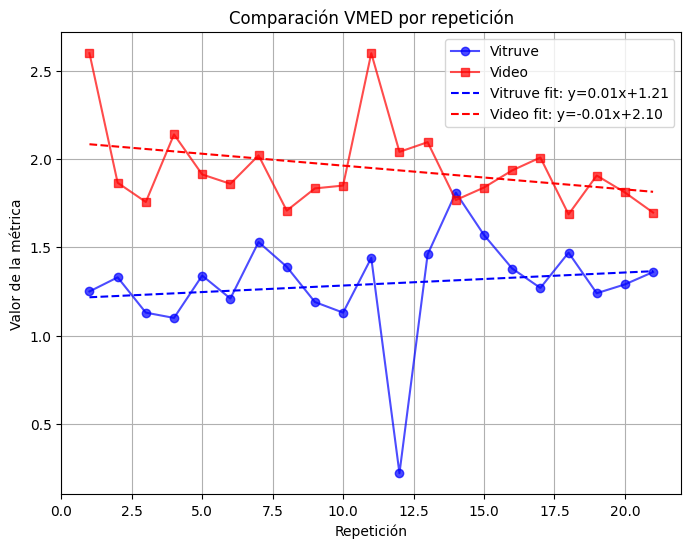

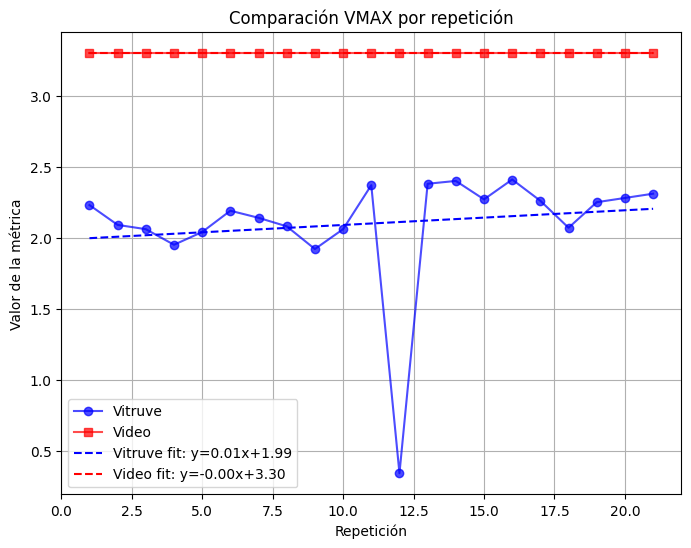

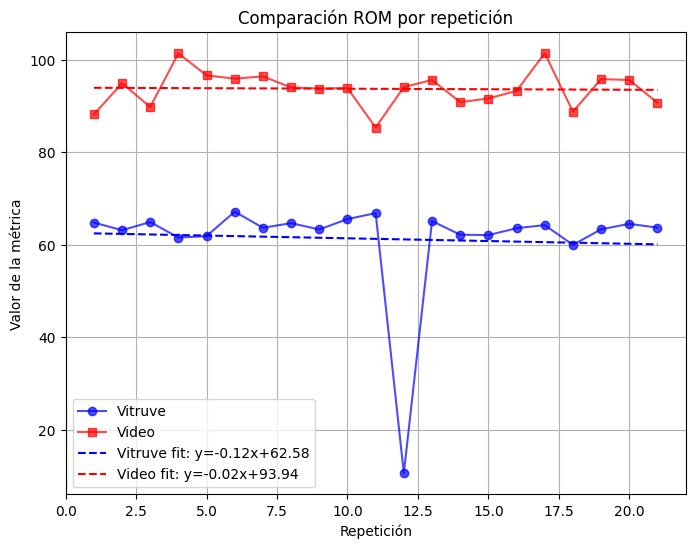

Ratio VMED (Vitruve/Video) = 0.6621885686370296
Ratio VMAX (Vitruve/Video) = 0.6363636363636365
Ratio ROM (Vitruve/Video) = 0.6540856656081128


In [26]:
df_curl_front1 = pd.read_csv('../data_export/curl/20250403_085759_curl_metrics.csv')
df_curl_front2 = pd.read_csv('../data_export/curl/20250403_090119_curl_metrics.csv')
df_video_curl_front = pd.concat([df_curl_front1, df_curl_front2], ignore_index=True)
df_video_curl_front['repetition_index'] = range(1, len(df_video_curl_front) + 1)
print(f"the reps count measured in video is: {df_video_curl_front.shape[0]}")

df_vitruve_curl_front =  df_vitruve[df_vitruve['Nº Serie'].isin([7,8])][df_vitruve['Tipo*']=='C']
df_vitruve_curl_front['repetition_index'] = range(1, len(df_vitruve_curl_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_curl_front.shape[0]}")



df_vitruve_curl_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_curl_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_curl_front = pd.merge(df_video_curl_front, df_vitruve_curl_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_curl_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_curl_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

plot_comparison_by_rep(df_curl_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_curl_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_curl_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_curl_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_curl_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_curl_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)


# Peso muerto

## Vista frontal

## Vista lateral

the reps count measured in video is: 21
the reps count measured in vitruve is: 22
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0289
 MAE: 0.1299
 MRE: 14.79%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0257
 MAE: 0.1159
 MRE: 8.50%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 16.9919
 MAE: 3.1688
 MRE: 6.73%



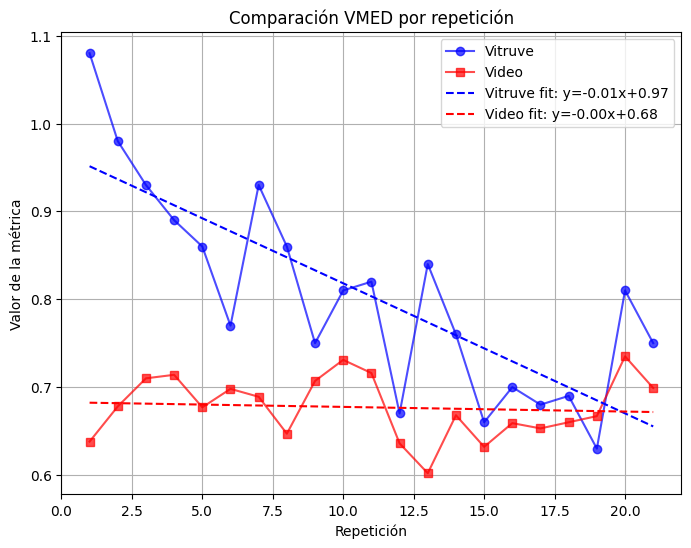

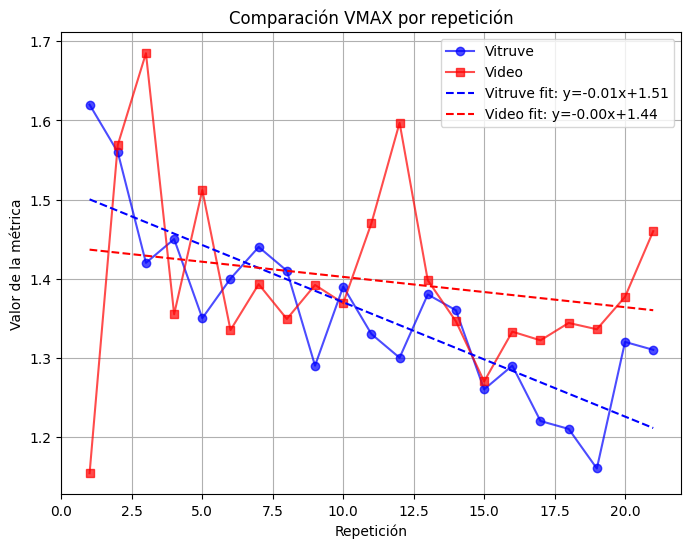

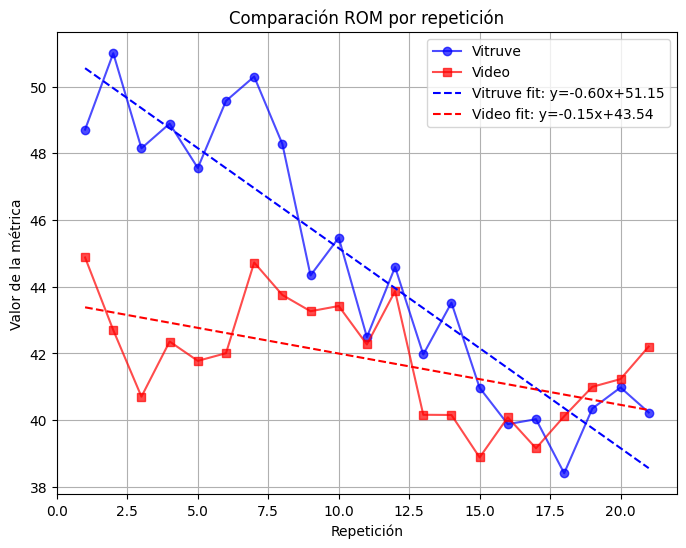

Ratio VMED (Vitruve/Video) = 1.1866910523353966
Ratio VMAX (Vitruve/Video) = 0.9694885241435675
Ratio ROM (Vitruve/Video) = 1.064818397418098


In [27]:
df_deadlift_lat1 = pd.read_csv('../data_export/deadlift/20250403_111917_deadlift_metrics.csv')
df_deadlift_lat2 = pd.read_csv('../data_export/deadlift/20250403_112407_deadlift_metrics.csv')
df_video_deadlift_lat = pd.concat([df_deadlift_lat1, df_deadlift_lat2], ignore_index=True)
df_video_deadlift_lat['repetition_index'] = range(1, len(df_video_deadlift_lat) + 1)
print(f"the reps count measured in video is: {df_video_deadlift_lat.shape[0]}")

df_vitruve_deadlift_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([11,12])][df_vitruve['Tipo*']=='C']
df_vitruve_deadlift_lat['repetition_index'] = range(1, len(df_vitruve_deadlift_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_deadlift_lat.shape[0]}")



df_vitruve_deadlift_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_deadlift_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_deadlift_lat = pd.merge(df_vitruve_deadlift_lat, df_video_deadlift_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_deadlift_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_deadlift_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_deadlift_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_deadlift_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_deadlift_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_deadlift_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

# Flexiones

## Vista frontal

the reps count measured in video is: 23
the reps count measured in vitruve is: 22
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.2908
 MAE: 0.5260
 MRE: 71.99%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0336
 MAE: 0.1594
 MRE: 13.52%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 46.5770
 MAE: 5.3973
 MRE: 15.62%



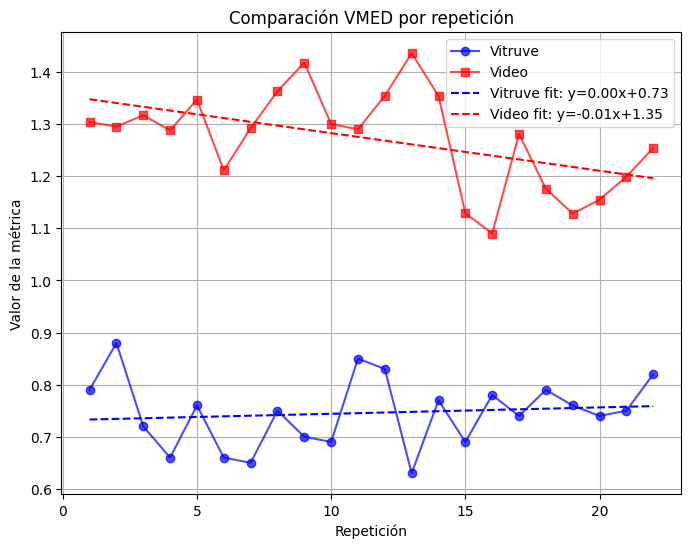

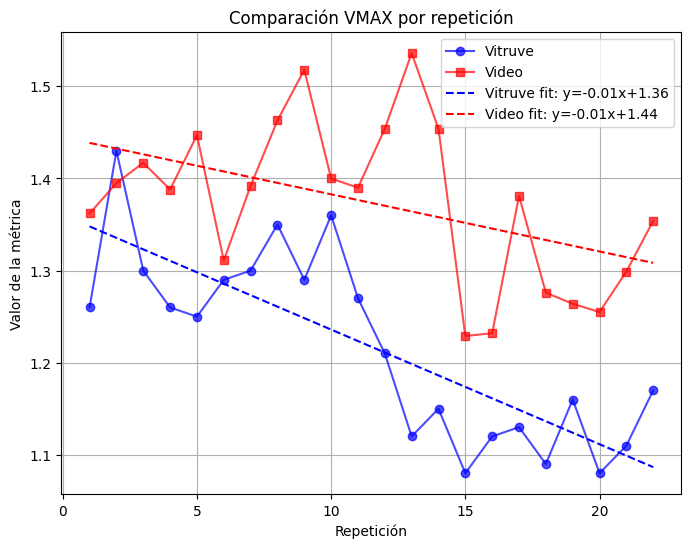

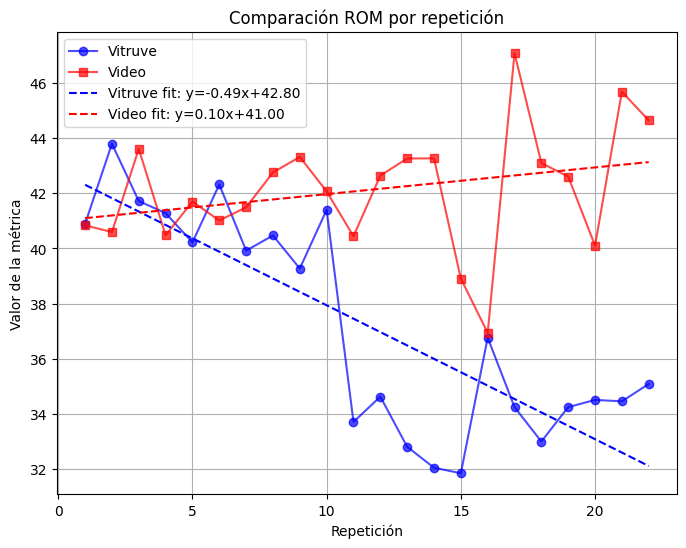

Ratio VMED (Vitruve/Video) = 0.5864693899431757
Ratio VMAX (Vitruve/Video) = 0.8862560810139989
Ratio ROM (Vitruve/Video) = 0.8834299812532175


In [28]:
df_pushup_front1 = pd.read_csv('../data_export/pushup/20250403_122616_pushup_metrics.csv')
df_pushup_front2 = pd.read_csv('../data_export/pushup/20250403_123112_pushup_metrics.csv')
df_video_pushup_front = pd.concat([df_pushup_front1, df_pushup_front2], ignore_index=True)
df_video_pushup_front['repetition_index'] = range(1, len(df_video_pushup_front) + 1)
print(f"the reps count measured in video is: {df_video_pushup_front.shape[0]}")

df_vitruve_pushup_front =  df_vitruve[df_vitruve['Nº Serie'].isin([13,14])][df_vitruve['Tipo*']=='C']
df_vitruve_pushup_front['repetition_index'] = range(1, len(df_vitruve_pushup_front) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_pushup_front.shape[0]}")

df_vitruve_pushup_front.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_pushup_front.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_pushup_front = pd.merge(df_video_pushup_front, df_vitruve_pushup_front, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_pushup_front[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_pushup_front[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

plot_comparison_by_rep(df_pushup_front, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_pushup_front, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_pushup_front, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_pushup_front[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_pushup_front[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_pushup_front[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

## Vista Lateral

the reps count measured in video is: 22
the reps count measured in vitruve is: 22
*** Comparando Vitruve_VMED vs Video_VMED ***
 MSE: 0.0254
 MAE: 0.1332
 MRE: 15.09%

*** Comparando Vitruve_VMAX vs Video_VMAX ***
 MSE: 0.0945
 MAE: 0.2579
 MRE: 20.40%

*** Comparando Vitruve_ROM vs Video_ROM ***
 MSE: 64.7211
 MAE: 7.2254
 MRE: 19.92%



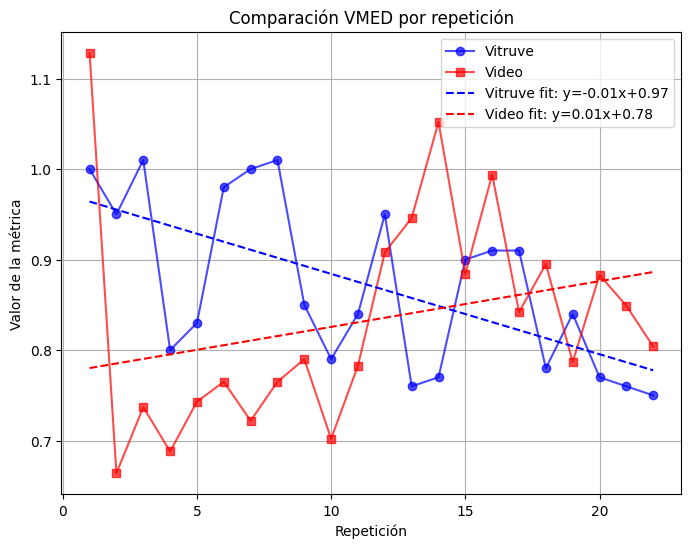

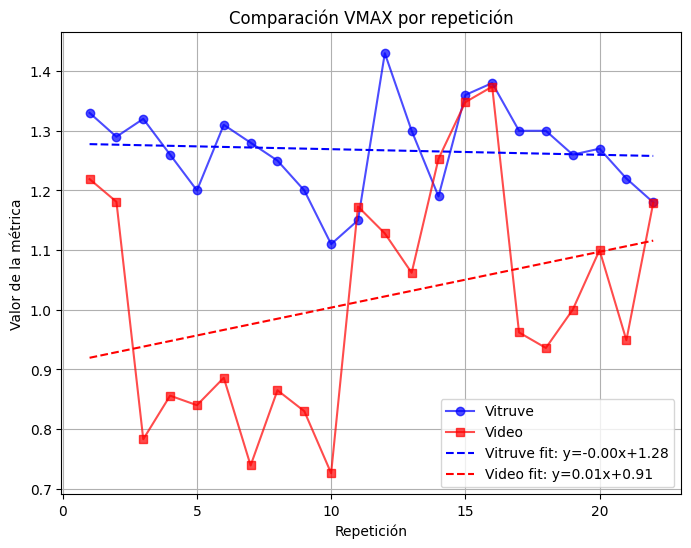

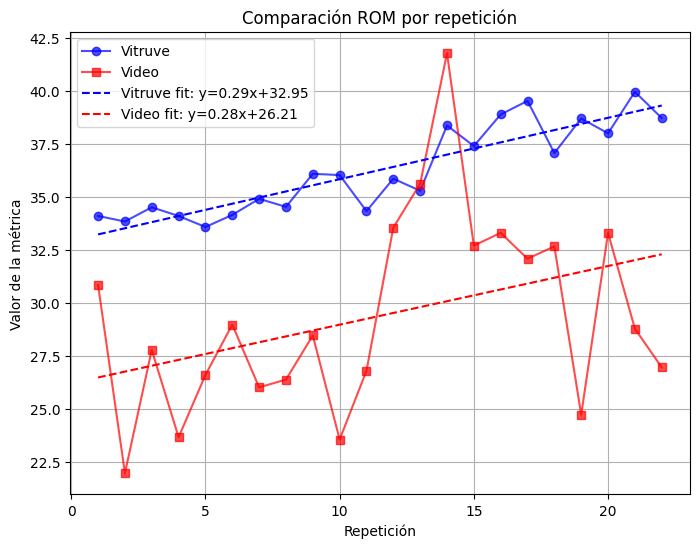

Ratio VMED (Vitruve/Video) = 1.0452239375920573
Ratio VMAX (Vitruve/Video) = 1.2457010138907498
Ratio ROM (Vitruve/Video) = 1.234220080778342


In [29]:
df_pushups_lat1 = pd.read_csv('../data_export/pushup/20250403_123452_pushup_metrics.csv')
df_pushups_lat2 = pd.read_csv('../data_export/pushup/20250403_123828_pushup_metrics.csv')
df_video_pushup_lat = pd.concat([df_pushups_lat1, df_pushups_lat2], ignore_index=True)
df_video_pushup_lat['repetition_index'] = range(1, len(df_video_pushup_lat) + 1)
print(f"the reps count measured in video is: {df_video_pushup_lat.shape[0]}")

df_vitruve_pushup_lat =  df_vitruve[df_vitruve['Nº Serie'].isin([15,16])][df_vitruve['Tipo*']=='C']
df_vitruve_pushup_lat['repetition_index'] = range(1, len(df_vitruve_pushup_lat) + 1)
print(f"the reps count measured in vitruve is: {df_vitruve_pushup_lat.shape[0]}")


df_vitruve_pushup_lat.rename(columns={
    'VMP (m/s)': 'Vitruve_VMED',
    'Velocidad máxima (m/s)': 'Vitruve_VMAX',
    'ROM (cm)': 'Vitruve_ROM'
}, inplace=True)
df_video_pushup_lat.rename(columns={
    'VMED (m/s)': 'Video_VMED',
    'VMAX (m/s)': 'Video_VMAX',
    'ROM (cm)': 'Video_ROM'
}, inplace=True)

df_pushup_lat = pd.merge(df_vitruve_pushup_lat, df_video_pushup_lat, how = 'inner', on = 'repetition_index')

for vitruve_col, video_col in metrics:
    # Extraemos las series
    y_true = df_pushup_lat[vitruve_col].astype(str).str.replace(',', '.').astype(float)
    y_pred = df_pushup_lat[video_col].astype(str).str.replace(',', '.').astype(float)
    
    # Calculamos MSE y MAE
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mre = mean_relative_error(y_true, y_pred)
    
    print(f"*** Comparando {vitruve_col} vs {video_col} ***")
    print(f" MSE: {mse:.4f}")
    print(f" MAE: {mae:.4f}")
    print(f" MRE: {mre:.2f}%\n")

plot_comparison_by_rep(df_pushup_lat, 'Vitruve_VMED', 'Video_VMED', "Comparación VMED por repetición")
plot_comparison_by_rep(df_pushup_lat, 'Vitruve_VMAX', 'Video_VMAX', "Comparación VMAX por repetición")
plot_comparison_by_rep(df_pushup_lat, 'Vitruve_ROM',  'Video_ROM',  "Comparación ROM por repetición")


df_vmed = df_pushup_lat[['Vitruve_VMED','Video_VMED']].dropna()
vitruve_mean_vmed = df_vmed['Vitruve_VMED'].astype(str).str.replace(',', '.').astype(float).mean()
video_mean_vmed   = df_vmed['Video_VMED'].astype(str).str.replace(',', '.').astype(float).mean()

ratio_vmed = vitruve_mean_vmed / video_mean_vmed
print("Ratio VMED (Vitruve/Video) =", ratio_vmed)

df_vmax = df_pushup_lat[['Vitruve_VMAX','Video_VMAX']].dropna()
vitruve_mean_vmax = (df_vmax['Vitruve_VMAX'].astype(str)
                                       .str.replace(',', '.')
                                       .astype(float)
                                       .mean())
video_mean_vmax   = (df_vmax['Video_VMAX'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
ratio_vmax = vitruve_mean_vmax / video_mean_vmax
print("Ratio VMAX (Vitruve/Video) =", ratio_vmax)

df_rom = df_pushup_lat[['Vitruve_ROM','Video_ROM']].dropna()
vitruve_mean_rom = (df_rom['Vitruve_ROM'].astype(str)
                                     .str.replace(',', '.')
                                     .astype(float)
                                     .mean())
video_mean_rom   = (df_rom['Video_ROM'].astype(str)
                                   .str.replace(',', '.')
                                   .astype(float)
                                   .mean())
ratio_rom = vitruve_mean_rom / video_mean_rom
print("Ratio ROM (Vitruve/Video) =", ratio_rom)

# Triceps banco